# AI-Powered Smart Energy Consumption Prediction
### Task 1: Dataset Selection & Data Preprocessing

**Submitted By:** Sarib Shahid

**Course:** AI / Machine Learning Internship

**Date:** 14 July 2026

# Problem Statement

Electricity consumption has become a major challenge in modern households due to inefficient energy usage and the inability to predict future consumption. This project aims to develop a machine learning model capable of predicting household appliance energy consumption using environmental and weather-related features. Accurate predictions can help reduce electricity costs, minimize energy waste, and support sustainable smart home management.

# Dataset Selection

**Dataset Name:** Appliance Energy Prediction Dataset

**Source:** Kaggle

**Dataset Link:** https://www.kaggle.com/datasets/loveall/appliances-energy-predictions

### Why this Dataset?

This dataset was selected because it contains real-world household appliance energy consumption data along with indoor environmental conditions, weather measurements, and time-based information. It is well suited for building a regression model that predicts future energy consumption for smart homes.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("energydata_complete.csv")

In [4]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


# Data Understanding

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (19735, 29)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [7]:
df.columns.tolist()

['date',
 'Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2']

## Target Variable

The target variable is **Appliances**, which represents the household appliance energy consumption measured in Watt-hours (Wh).

Since the target contains continuous numerical values, this is a **Supervised Machine Learning Regression Problem**.

## Statistical Summary

Summary statistics help us understand the distribution, central tendency, and spread of numerical features.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


## Dataset Dimensions

The first step is to determine the size of the dataset by identifying the number of rows (observations) and columns (features).

In [9]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 19735
Number of Columns: 29


## Feature Names

The dataset contains environmental, weather, and appliance energy consumption features collected from a smart home.`

In [10]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

## Data Types

Let's inspect the data types of each feature to identify numerical, categorical, and datetime attributes.

In [11]:
df.dtypes

date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

## Missing Value Analysis

Checking whether the dataset contains missing values that require preprocessing.

In [12]:
missing_values = df.isnull().sum()

missing_values

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Observation:

The dataset does not contain any missing values; therefore, no imputation techniques were required.

## Duplicate Record Analysis

Duplicate records can negatively impact model performance, so we check whether duplicate observations exist.

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


Observation:

No duplicate records were found in the dataset. Therefore, no duplicate removal was necessary.

## Class Distribution

Class distribution analysis is applicable only to classification problems.

Since this project predicts continuous appliance energy consumption (Wh), it is a regression problem. Therefore, class distribution analysis is not applicable.

# Data Preprocessing

## 1. Handling Missing Values

Missing values can negatively affect machine learning models. Therefore, the dataset is checked for null values before further preprocessing.

In [21]:
missing_values = df.isnull().sum()

missing_values

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
Year           0
Month          0
Day            0
Hour           0
Minute         0
DayOfWeek      0
IsWeekend      0
dtype: int64

## 2. Duplicate Record Analysis

Duplicate records can introduce bias into the model. Therefore, duplicate entries are checked and removed if necessary.

In [22]:
df.drop_duplicates(inplace=True)

## 3. Outlier Detection

Outliers are detected using the Interquartile Range (IQR) method. Outlier detection helps identify unusually high or low values that may affect model performance.

In [14]:
Q1 = df["Appliances"].quantile(0.25)
Q3 = df["Appliances"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Appliances"] < lower_bound) | (df["Appliances"] > upper_bound)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2138


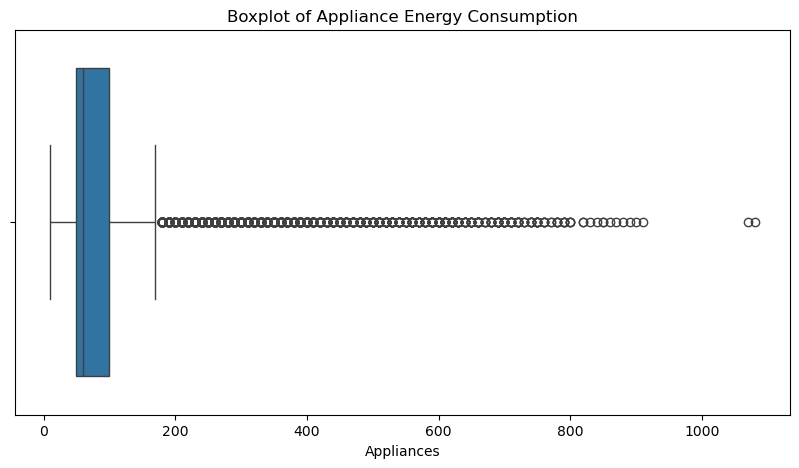

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Appliances"])

plt.title("Boxplot of Appliance Energy Consumption")

plt.show()

### Observation

Outliers were detected in the target variable. However, these values represent genuine periods of high household energy consumption rather than data entry errors. Therefore, they were retained to preserve realistic consumption patterns and improve the model's ability to predict peak energy usage.

## 4. Encoding Categorical Variables

Machine learning models require numerical data. Therefore, categorical variables are identified before deciding whether encoding is required.

In [16]:
df.select_dtypes(include="object").columns

Index(['date'], dtype='object')

### Observation

The dataset does not contain categorical variables requiring Label Encoding or One-Hot Encoding.

The only non-numeric column is `date`, which will be converted into meaningful numerical time-based features during feature engineering instead of being encoded as a categorical variable.

## Feature Engineering

The `date` column contains timestamp information. Instead of using it as a raw text feature, it is converted into multiple numerical time-based features that can help the machine learning model identify temporal patterns in energy consumption.

In [17]:
df["date"] = pd.to_datetime(df["date"])

df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Day"] = df["date"].dt.day
df["Hour"] = df["date"].dt.hour
df["Minute"] = df["date"].dt.minute
df["DayOfWeek"] = df["date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df.drop("date", axis=1, inplace=True)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Tdewpoint,rv1,rv2,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,5.3,13.275433,13.275433,2016,1,11,17,0,0,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,5.2,18.606195,18.606195,2016,1,11,17,10,0,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,5.1,28.642668,28.642668,2016,1,11,17,20,0,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,5.0,45.410389,45.410389,2016,1,11,17,30,0,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,4.9,10.084097,10.084097,2016,1,11,17,40,0,0


The original `date` column was transformed into seven numerical features (Year, Month, Day, Hour, Minute, DayOfWeek, and IsWeekend). These features provide meaningful temporal information that can improve the model's ability to learn energy consumption patterns.

## Removing Irrelevant Features

The dataset contains two randomly generated variables (`rv1` and `rv2`). These variables do not have any physical meaning and are not expected to contribute to predicting appliance energy consumption. Therefore, they are removed.

In [18]:
df.drop(["rv1", "rv2"], axis=1, inplace=True)

df.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek',
       'IsWeekend'],
      dtype='object')

The features `rv1` and `rv2` were removed because they are randomly generated variables without meaningful predictive information.

## Feature Scaling

The dataset contains features measured on different scales, such as temperature, humidity, atmospheric pressure, wind speed, and visibility. Standardization is applied to ensure that all features contribute equally during model training.

In [19]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Appliances", axis=1)
y = df["Appliances"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


StandardScaler was used to standardize the feature values. This transformation converts each feature to have a mean of 0 and a standard deviation of 1, improving the performance of many machine learning algorithms.

## Class Imbalance Analysis

Class imbalance analysis is applicable only to classification problems.

Since the target variable (`Appliances`) contains continuous numerical values, this project is a regression problem. Therefore, class imbalance analysis is not required.

## SMOTE-Tomek

SMOTE-Tomek is a data balancing technique used for classification problems with imbalanced classes.

This project predicts continuous appliance energy consumption values, making it a regression problem rather than a classification problem. Therefore, SMOTE-Tomek was not applied.

## Save the Preprocessed Dataset

After completing all preprocessing steps, the cleaned dataset is saved for use in the model training phase.

In [20]:
df.to_csv("energy_preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


# Conclusion

The dataset was successfully prepared for machine learning by performing comprehensive preprocessing. The process included checking for missing values and duplicates, detecting outliers, extracting time-based features from the `date` column, removing irrelevant variables (`rv1` and `rv2`), and applying feature scaling using StandardScaler. Since this is a regression problem, class imbalance analysis and SMOTE-Tomek were not applicable. The final preprocessed dataset is clean and ready for model training and evaluation.